In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# Loading data

In [2]:
df = pd.read_parquet('../data/processed/feature_engineered.parquet')

In [3]:
df_dashboard = df.copy()

In [4]:
pd.set_option('display.max_columns', None)

# Temporary Checking Feature Importance

In [5]:
df_sample = df.sample(frac=0.2, random_state=42)

drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
    
]

df_sample = df_sample.drop(columns=drop_cols)

low_card_cols = ['payment_type', 'customer_state', 'product_category_name']
df_sample = pd.get_dummies(df_sample, columns=low_card_cols, drop_first=True)

df_sample = df_sample.copy()

X = df_sample.drop(columns=['log_payment_value', 'payment_value'])
y = df_sample['log_payment_value']

model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    tree_method="hist",
    device="cuda",
    random_state=42
)

model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importance.head(20))

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [15:03:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [15:03:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


product_category_name_garden_tools                               0.035156
product_category_name_construction_tools_construction            0.025357
payment_type_voucher                                             0.024620
product_category_name_industry_commerce_and_business             0.023295
product_category_name_telephony                                  0.022500
total_cost                                                       0.021641
customer_state_PE                                                0.020457
product_category_name_sports_leisure                             0.020116
shipping_ratio                                                   0.020052
product_category_name_baby                                       0.019940
product_category_name_kitchen_dining_laundry_garden_furniture    0.019791
payment_type_debit_card                                          0.019609
customer_state_MS                                                0.019215
product_category_name_computers_access

# Insighs

- Important

product_category_name_* → VERY important

payment_type_* → important

customer_state_* → important

total_cost → important

shipping_ratio → important

product features (height, volume, density) → useful

- Not Important

price

payment_value components directly

most time features

city (we dropped — good decision)

In [6]:
top_categories = df['product_category_name'].value_counts().nlargest(10).index
df['top_category'] = df['product_category_name'].isin(top_categories).astype(int)

### Droping UnImportant Columns

drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_model = df.drop(columns=drop_cols)

In [7]:
drop_cols = [
    'order_id', 'customer_id',
    'product_id', 'seller_id',
    'customer_city',
    'customer_zip_code_prefix',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_model = df.drop(columns=drop_cols)

In [8]:
X = df_model.drop(columns=['payment_value', 'log_payment_value'])
y = df_model['log_payment_value']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87413 non-null  category      
 1   customer_id                    87413 non-null  category      
 2   order_status                   87413 non-null  category      
 3   order_purchase_timestamp       87413 non-null  datetime64[ns]
 4   order_approved_at              87413 non-null  datetime64[ns]
 5   order_delivered_timestamp      87413 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87413 non-null  datetime64[ns]
 7   payment_sequential             87413 non-null  int64         
 8   payment_type                   87413 non-null  category      
 9   payment_installments           87413 non-null  int16         
 10  payment_value                  87413 non-null  float64       
 11  product_id     

In [10]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,payment_sequential,payment_installments,payment_value,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value,top_category
count,87413,87413,87413,87413,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,2017-12-29 22:08:00.051639808,2017-12-30 08:30:16.404482048,2018-01-11 08:33:03.465502976,2018-01-22 18:57:26.837426944,1.097400,2.963987,268.788524,342.292224,44.244648,2081.968506,30.199352,16.528275,23.026655,15178.513539,11.968689,10.292836,-12.012367,386.536872,0.826308,0.182799,6.032856,2.746182,0.225641,2.363521,0.368378,1.982039,0.293869,0.499685,0.499743,0.288424,5.045839,0.908503
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-11 13:46:32,2016-10-27 00:00:00,1.000000,0.000000,0.000000,0.850000,0.000000,2.000000,7.000000,2.000000,6.000000,168.000000,0.000000,0.000000,-30.000000,1.140000,0.000000,0.000318,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-09-10 20:15:46,2017-09-11 15:30:18,2017-09-20 20:27:47,2017-10-02 00:00:00,1.000000,1.000000,84.330000,59.650000,20.040000,300.000000,18.000000,8.000000,15.000000,2856.000000,6.000000,0.215278,-17.000000,107.720000,0.072984,0.067200,3.000000,1.000000,0.000000,1.945910,0.070443,1.000000,0.000000,0.000000,0.000000,0.000000,4.446526,1.000000
50%,2018-01-17 11:59:12,2018-01-17 16:35:21,2018-01-30 22:48:40,2018-02-14 00:00:00,1.000000,2.000000,171.860000,136.900000,35.010000,700.000000,25.000000,13.000000,20.000000,6555.000000,10.000000,0.344722,-13.000000,184.750000,0.221800,0.112000,6.000000,3.000000,0.000000,2.397895,0.200325,2.000000,0.000000,0.000000,0.000000,0.000000,5.152482,1.000000
75%,2018-05-02 23:06:51,2018-05-03 09:12:19,2018-05-14 15:54:50,2018-05-24 00:00:00,1.000000,4.000000,313.550000,399.200000,57.150000,1800.000000,38.000000,20.000000,30.000000,18375.000000,15.000000,14.833056,-7.000000,438.450000,0.607091,0.191250,8.000000,4.000000,0.000000,2.772589,0.474425,3.000000,1.000000,1.000000,1.000000,1.000000,5.751143,1.000000
max,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-10-17 13:22:46,2018-10-25 00:00:00,26.000000,24.000000,7274.880000,6735.000000,409.680000,40425.000000,105.000000,105.000000,118.000000,294000.000000,209.000000,168.000000,30.000000,6738.820000,205.279938,10.000000,12.000000,6.000000,1.000000,5.347108,5.329234,4.000000,1.000000,1.000000,1.000000,1.000000,8.892320,1.000000
std,NaN,NaN,NaN,NaN,0.742207,2.794934,344.834902,559.776730,37.657927,3734.926025,16.051746,13.366062,11.670736,23139.189494,9.277935,19.754494,8.934977,560.813861,4.051982,0.353039,3.231184,1.957856,0.418006,0.634378,0.479195,1.401218,0.455535,0.500003,0.500003,0.453032,1.134738,0.288316


# Model 0 Training - Product Value Prediction

## TRAIN-TEST SPLIT

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
categorical_cols = [
    'payment_type',
    'customer_state',
    'product_category_name'
]

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### XGBoost

In [13]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",   # remove if no GPU
    random_state=42
)

model.fit(X_train, y_train)

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [15:03:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_01\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [15:03:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 177.59848322445427
RMSE: 355.4907481474982
R2 Score: -0.06654239044626209


### Linear Regression

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = np.expm1(lr.predict(X_test))

print("LR R2:", r2_score(y_true, y_pred))

LR R2: -0.11055726796233656


### Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = np.expm1(rf.predict(X_test))

print("RF R2:", r2_score(y_true, y_pred))

RF R2: -0.07544914244014289


### XGBoost Tuned

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = np.expm1(xgb.predict(X_test))

print("XGB R2:", r2_score(y_true, y_pred))

XGB R2: -0.06516079396748586


### LightGBM

In [18]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred = np.expm1(lgb.predict(X_test))

print("LGBM R2:", r2_score(y_true, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3065
[LightGBM] [Info] Number of data points in the train set: 69930, number of used features: 104
[LightGBM] [Info] Start training from score 5.042887
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

# Insights
Model is not giving accurate results, so we change the objective
- High Value Order Prediction
- Delivery Delay Prediction

In [19]:
df_model.head()

,payment_sequential,payment_type,payment_installments,payment_value,price,shipping_charges,customer_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value,top_category
0,1,credit_card,1,259.14,223.51,84.65,SP,toys,491.0,19.0,12.0,16.0,3648.0,4,0.271944,-14,308.16,0.378730,0.134594,10,6,1,1.609438,0.321163,3,0,1,0,0,5.561220,1
1,1,credit_card,8,382.39,170.80,23.79,RJ,watches_gifts,440.0,18.0,14.0,17.0,4284.0,13,0.663611,-21,194.59,0.139286,0.102708,6,2,0,2.639057,0.130401,2,0,1,0,1,5.949053,1
2,1,credit_card,4,249.25,64.40,17.38,SP,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,10,23.934444,-9,81.78,0.269876,0.537109,2,4,0,2.397895,0.238919,1,0,0,0,1,5.522460,0
3,1,credit_card,2,27.79,264.50,30.72,MG,toys,1450.0,68.0,3.0,48.0,9792.0,9,0.179722,-23,295.22,0.116144,0.148080,8,5,1,2.302585,0.109880,3,0,1,1,0,3.360028,1
4,1,credit_card,1,76.15,779.90,30.66,SP,toys,300.0,17.0,4.0,12.0,816.0,14,0.790833,-13,810.56,0.039313,0.367647,12,4,0,2.708050,0.038560,4,0,1,0,0,4.345752,1


In [20]:
df = df_model.copy()

In [21]:
drop_cols = [
    'log_payment_value', 

    'price',
    'shipping_charges',
    'shipping_ratio',

    'product_length_cm',
    'product_width_cm',
    
    'delivery_time_days',
    
    'order_dayofweek',
]

df = df.drop(columns=drop_cols)

In [22]:
final_features = [
    # Payment
    'payment_type',
    'payment_installments',
    'payment_sequential',

    # Cost
    'total_cost',
    'log_shipping_ratio',

    # Product
    'product_category_name',
    'product_weight_g',
    'product_volume_cm3',
    'product_density',
    'product_height_cm',

    # Customer
    'customer_state',

    # Time
    'approval_time_hours',
    'delivery_delay_days',
    'log_delivery_time',
    'order_month',
    'is_weekend',

    # Engineered
    'price_bucket',
    'high_shipping',
    'is_expensive',
    'is_large_product',
    'high_installments',
    'top_category'
]

In [23]:
df_final = df[final_features].copy()

In [24]:
df.shape

(87413, 23)

In [25]:
df_final_new = df.copy()

# Model 1 Product Classification

## Trying Multi class if didnt work then move to only high value.

In [26]:
q50 = df['payment_value'].quantile(0.50)
q75 = df['payment_value'].quantile(0.75)

def categorize(value):
    if value <= q50:
        return 0   # Normal
    elif value <= q75:
        return 1   # High
    else:
        return 2   # Premium

df_final['value_segment'] = df['payment_value'].apply(categorize)

In [27]:
df_final['value_segment'].value_counts(normalize=True)

value_segment
0    0.500006
1    0.250009
2    0.249986
Name: proportion, dtype: float64

In [28]:
categorical_cols = [
    'payment_type',
    'customer_state',
    'product_category_name'
]

df_final = pd.get_dummies(df_final, columns=categorical_cols, drop_first=True)

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5249099124864154
              precision    recall  f1-score   support

           0       0.52      0.98      0.68      8736
           1       0.68      0.05      0.10      4399
           2       0.67      0.08      0.14      4348

    accuracy                           0.52     17483
   macro avg       0.62      0.37      0.31     17483
weighted avg       0.60      0.52      0.40     17483



In [30]:
X_train.head()

,payment_installments,payment_sequential,total_cost,log_shipping_ratio,product_weight_g,product_volume_cm3,product_density,product_height_cm,approval_time_hours,delivery_delay_days,log_delivery_time,order_month,is_weekend,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,product_category_name_air_conditioning,product_category_name_art,product_category_name_arts_and_craftmanship,product_category_name_audio,product_category_name_auto,product_category_name_baby,product_category_name_bed_bath_table,product_category_name_books_general_interest,product_category_name_books_imported,product_category_name_books_technical,product_category_name_christmas_supplies,product_category_name_cine_photo,product_category_name_computers,product_category_name_computers_accessories,product_category_name_consoles_games,product_category_name_construction_tools_construction,product_category_name_construction_tools_lights,product_category_name_construction_tools_safety,product_category_name_cool_stuff,product_category_name_costruction_tools_garden,product_category_name_costruction_tools_tools,product_category_name_diapers_and_hygiene,product_category_name_drinks,product_category_name_dvds_blu_ray,product_category_name_electronics,product_category_name_fashio_female_clothing,product_category_name_fashion_bags_accessories,product_category_name_fashion_childrens_clothes,product_category_name_fashion_male_clothing,product_category_name_fashion_shoes,product_category_name_fashion_sport,product_category_name_fashion_underwear_beach,product_category_name_fixed_telephony,product_category_name_flowers,product_category_name_food,product_category_name_food_drink,product_category_name_furniture_bedroom,product_category_name_furniture_decor,product_category_name_furniture_living_room,product_category_name_furniture_mattress_and_upholstery,product_category_name_garden_tools,product_category_name_health_beauty,product_category_name_home_appliances,product_category_name_home_appliances_2,product_category_name_home_comfort_2,product_category_name_home_confort,product_category_name_home_construction,product_category_name_housewares,product_category_name_industry_commerce_and_business,product_category_name_kitchen_dining_laundry_garden_furniture,product_category_name_la_cuisine,product_category_name_luggage_accessories,product_category_name_market_place,product_category_name_music,product_category_name_musical_instruments,product_category_name_office_furniture,product_category_name_party_supplies,product_category_name_perfumery,product_category_name_pet_shop,product_category_name_security_and_services,product_category_name_signaling_and_security,product_category_name_small_appliances,product_category_name_small_appliances_home_oven_and_coffee,product_category_name_sports_leisure,product_category_name_stationery,product_category_name_tablets_printing_image,product_category_name_telephony,product_category_name_toys,product_category_name_unknown,product_category_name_watches_gifts
11035,1,1,167.31,0.073846,450.0,17280.0,0.026042,8.0,0.461944,-1,1.945910,7,0,2,0,1,1,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

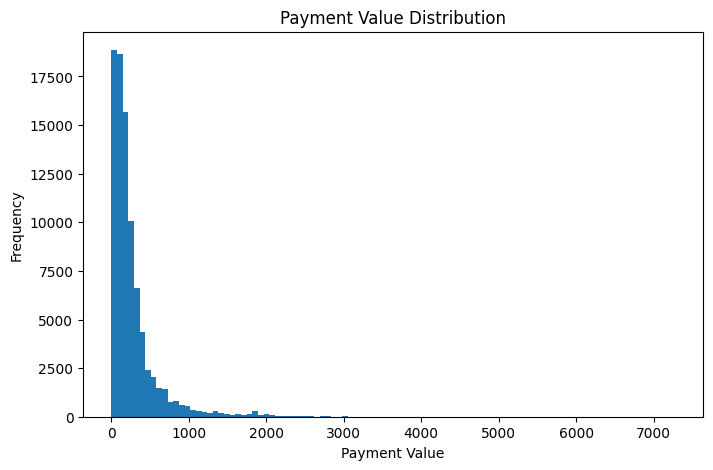

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['payment_value'], bins=100)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()

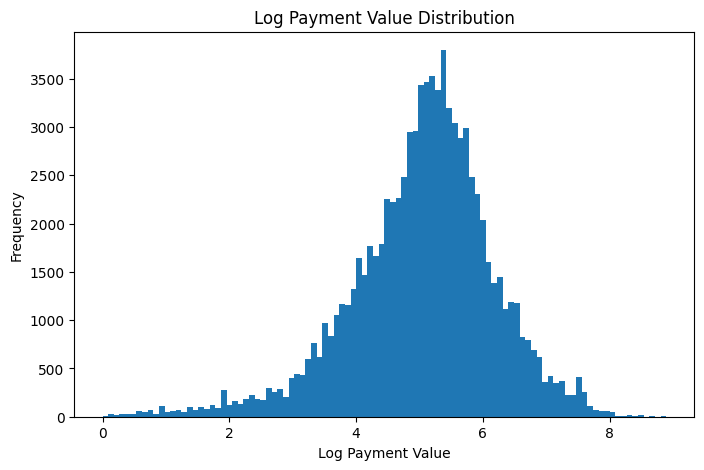

In [32]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['payment_value']), bins=100)
plt.title("Log Payment Value Distribution")
plt.xlabel("Log Payment Value")
plt.ylabel("Frequency")
plt.show()

In [33]:
percentiles = df['payment_value'].quantile(
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
)

print(percentiles)

0.10     37.100
0.20     67.230
0.30    100.470
0.40    135.528
0.50    171.860
0.60    214.090
0.70    272.958
0.80    363.712
0.90    579.930
0.95    852.680
Name: payment_value, dtype: float64


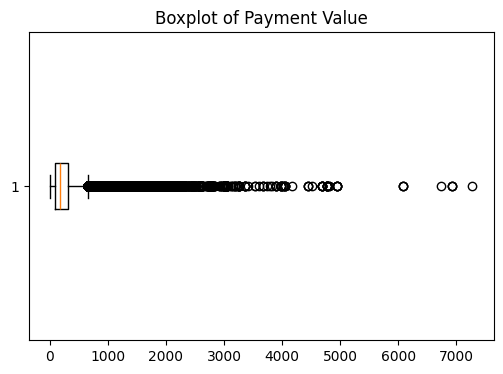

In [34]:
plt.figure(figsize=(6,4))
plt.boxplot(df['payment_value'], vert=False)
plt.title("Boxplot of Payment Value")
plt.show()

In [35]:
def categorize(value):
    if value <= 135:
        return 0
    elif value <= 364:
        return 1
    else:
        return 2

df_final['value_segment'] = df['payment_value'].apply(categorize)

In [36]:
df_final['value_segment'].value_counts(normalize=True)

value_segment
1    0.402961
0    0.397458
2    0.199581
Name: proportion, dtype: float64

In [37]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    scale_pos_weight=2,
    random_state=42
)

In [38]:
class_weights = {
    0: 1,
    1: 1,
    2: 2   # give more importance to premium
}

## FINAL Multiclass Model

In [39]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Prepare data
X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Compute weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Model
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train with weights
model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5044328776525768
              precision    recall  f1-score   support

           0       0.55      0.52      0.54      6865
           1       0.56      0.51      0.53      7151
           2       0.36      0.47      0.41      3467

    accuracy                           0.50     17483
   macro avg       0.49      0.50      0.49     17483
weighted avg       0.52      0.50      0.51     17483



### Tuning xgboost

In [40]:
model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,                # prevents overfitting
    min_child_weight=5,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

In [41]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5044328776525768
              precision    recall  f1-score   support

           0       0.55      0.52      0.54      6865
           1       0.56      0.51      0.53      7151
           2       0.36      0.47      0.41      3467

    accuracy                           0.50     17483
   macro avg       0.49      0.50      0.49     17483
weighted avg       0.52      0.50      0.51     17483



In [43]:
y_pred = model.predict(X_test)

In [ ]:
import numpy as np
import pandas as pd

# ADD NEW FEATURE
df_final['cost_per_volume'] = df['total_cost'] / (df['product_volume_cm3'] + 1)

# CREATE TARGET (MULTICLASS)
def categorize(value):
    if value <= 135:
        return 0   # Normal
    elif value <= 364:
        return 1   # High
    else:
        return 2   # Premium

df_final['value_segment'] = df['payment_value'].apply(categorize)


# ================================
# 3. DEFINE FEATURES & TARGET
# ================================
X = df_final.drop(columns=['value_segment'])
y = df_final['value_segment']


# ================================
# 4. TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ================================
# 5. CLASS WEIGHTS
# ================================
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)


# ================================
# 6. TRAIN MODEL (TUNED XGBOOST)
# ================================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    min_child_weight=5,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)


# ================================
# 7. EVALUATION
# ================================
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5204484356231768

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.53      0.55      6865
           1       0.57      0.53      0.55      7151
           2       0.38      0.49      0.43      3467

    accuracy                           0.52     17483
   macro avg       0.51      0.52      0.51     17483
weighted avg       0.53      0.52      0.52     17483



##### Multiclass can only be improved till 5% accuracy, lets keep it secondary for dashboard and use normal classification.

## Model 1 Final - High Value Classification

In [45]:
threshold = df['payment_value'].quantile(0.75)

df_final['high_value'] = (df['payment_value'] > threshold).astype(int)

In [46]:
X = df_final.drop(columns=['value_segment', 'high_value'])
y = df_final['high_value']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [49]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [50]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6823771663902076
              precision    recall  f1-score   support

           0       0.83      0.73      0.77     13135
           1       0.40      0.55      0.46      4348

    accuracy                           0.68     17483
   macro avg       0.61      0.64      0.62     17483
weighted avg       0.72      0.68      0.70     17483



### Tuning

In [51]:
y_prob = model.predict_proba(X_test)[:, 1]

In [52]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])

print(results_df)

    threshold  precision    recall        f1
0        0.10   0.248770  1.000000  0.398424
1        0.15   0.249455  0.999770  0.399284
2        0.20   0.250505  0.998390  0.400517
3        0.25   0.252464  0.995630  0.402791
4        0.30   0.256852  0.987121  0.407636
5        0.35   0.265965  0.964581  0.416961
6        0.40   0.284520  0.908004  0.433275
7        0.45   0.322194  0.767249  0.453816
8        0.50   0.398892  0.546688  0.461240
9        0.55   0.520695  0.324057  0.399490
10       0.60   0.638554  0.182843  0.284284
11       0.65   0.748377  0.106026  0.185737
12       0.70   0.816393  0.057268  0.107028
13       0.75   0.821705  0.024379  0.047353
14       0.80   0.916667  0.012649  0.024955
15       0.85   1.000000  0.002070  0.004131


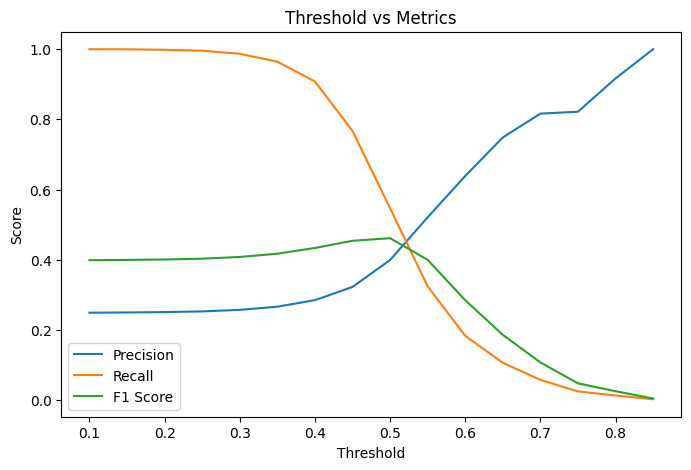

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.show()

In [54]:
quantiles = [0.70, 0.75, 0.80, 0.85]

In [55]:
for q in quantiles:
    threshold_val = df['payment_value'].quantile(q)
    
    df_final['high_value'] = (df['payment_value'] > threshold_val).astype(int)
    
    print(f"\nQuantile: {q}")
    print(df_final['high_value'].value_counts(normalize=True))


Quantile: 0.7
high_value
0    0.699999
1    0.300001
Name: proportion, dtype: float64

Quantile: 0.75
high_value
0    0.750014
1    0.249986
Name: proportion, dtype: float64

Quantile: 0.8
high_value
0    0.799995
1    0.200005
Name: proportion, dtype: float64

Quantile: 0.85
high_value
0    0.850034
1    0.149966
Name: proportion, dtype: float64


Enchanments

In [56]:
import numpy as np
import pandas as pd

# ================================
# 1. CREATE TARGET
# ================================
threshold_val = df['payment_value'].quantile(0.75)
df_final['high_value'] = (df['payment_value'] > threshold_val).astype(int)

# ================================
# 2. FEATURES & TARGET
# ================================
X = df_final.drop(columns=['value_segment', 'high_value'], errors='ignore')
y = df_final['high_value'].astype(int)

# ================================
# 3. TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Safety check
assert set(y_train.unique()) <= {0,1}
assert set(y_test.unique()) <= {0,1}

# ================================
# 4. HANDLE CLASS IMBALANCE
# ================================
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# ================================
# 5. TRAIN BEST MODEL (XGBOOST)
# ================================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# ================================
# 6. CALIBRATION
# ================================
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)

# ================================
# 7. FINAL PREDICTIONS (FIXED)
# ================================
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# 🔥 IMPORTANT: tuned threshold for better recall
best_threshold = 0.30

y_pred = (y_prob >= best_threshold).astype(int)

# ================================
# 8. FINAL METRICS
# ================================
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7351713092718641

ROC-AUC: 0.6827839935508023

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.83     13135
           1       0.46      0.37      0.41      4348

    accuracy                           0.74     17483
   macro avg       0.63      0.61      0.62     17483
weighted avg       0.72      0.74      0.73     17483


Confusion Matrix:

[[11225  1910]
 [ 2720  1628]]


In [57]:
for t in [0.25, 0.30, 0.35]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.83      0.69      0.75     13135
           1       0.38      0.57      0.45      4348

    accuracy                           0.66     17483
   macro avg       0.60      0.63      0.60     17483
weighted avg       0.72      0.66      0.68     17483


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.80      0.85      0.83     13135
           1       0.46      0.37      0.41      4348

    accuracy                           0.74     17483
   macro avg       0.63      0.61      0.62     17483
weighted avg       0.72      0.74      0.73     17483


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.79      0.93      0.85     13135
           1       0.54      0.26      0.35      4348

    accuracy                           0.76     17483
   macro avg       0.66      0.59      0.60     17483
weighted avg       0.73 

In [58]:
# ================================
# 9. SAVE MODEL
# ================================
import joblib

model_artifact = {
    "model": calibrated_model,
    "threshold": 0.25
}

joblib.dump(model_artifact, "../models/high_value_model.pkl")

['../models/high_value_model.pkl']

In [59]:
joblib.dump(X_train.columns.tolist(), "../models/high_value_columns.pkl")

['../models/high_value_columns.pkl']

# Model 2 - Delivery Delay Prediction

In [60]:
df_final_new['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

print(df_final_new['is_delayed'].value_counts())
print(df_final_new['is_delayed'].value_counts(normalize=True))

is_delayed
0    81809
1     5604
Name: count, dtype: int64
is_delayed
0    0.935891
1    0.064109
Name: proportion, dtype: float64


In [61]:
df_final_new.head()

,payment_sequential,payment_type,payment_installments,payment_value,customer_state,product_category_name,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,is_delayed
0,1,credit_card,1,259.14,SP,toys,491.0,12.0,3648.0,0.271944,-14,308.16,0.134594,10,1,1.609438,0.321163,3,0,1,0,0,1,0
1,1,credit_card,8,382.39,RJ,watches_gifts,440.0,14.0,4284.0,0.663611,-21,194.59,0.102708,6,0,2.639057,0.130401,2,0,1,0,1,1,0
2,1,credit_card,4,249.25,SP,costruction_tools_garden,2200.0,16.0,4096.0,23.934444,-9,81.78,0.537109,2,0,2.397895,0.238919,1,0,0,0,1,0,0
3,1,credit_card,2,27.79,MG,toys,1450.0,3.0,9792.0,0.179722,-23,295.22,0.148080,8,1,2.302585,0.109880,3,0,1,1,0,1,0
4,1,credit_card,1,76.15,SP,toys,300.0,4.0,816.0,0.790833,-13,810.56,0.367647,12,0,2.708050,0.038560,4,0,1,0,0,1,0


In [62]:
df_final_new.describe()

,payment_sequential,payment_installments,payment_value,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,is_delayed
count,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000,87413.000000
mean,1.097400,2.963987,268.788524,2081.968506,16.528275,15178.513539,10.292836,-12.012367,386.536872,0.182799,6.032856,0.225641,2.363521,0.368378,1.982039,0.293869,0.499685,0.499743,0.288424,0.908503,0.064109
std,0.742207,2.794934,344.834902,3734.926025,13.366062,23139.189494,19.754494,8.934977,560.813861,0.353039,3.231184,0.418006,0.634378,0.479195,1.401218,0.455535,0.500003,0.500003,0.453032,0.288316,0.244949
min,1.000000,0.000000,0.000000,2.000000,2.000000,168.000000,0.000000,-30.000000,1.140000,0.000318,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,84.330000,300.000000,8.000000,2856.000000,0.215278,-17.000000,107.720000,0.067200,3.000000,0.000000,1.945910,0.070443,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,2.000000,171.860000,700.000000,13.000000,6555.000000,0.344722,-13.000000,184.750000,0.112000,6.000000,0.000000,2.397895,0.200325,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,4.000000,313.550000,1800.000000,20.000000,18375.000000,14.833056,-7.000000,438.450000,0.191250,8.000000,0.000000,2.772589,0.474425,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,26.000000,24.000000,7274.880000,40425.000000,105.000000,294000.000000,168.000000,30.000000,6738.820000,10.000000,12.000000,1.000000,5.347108,5.329234,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
df_final_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   payment_sequential     87413 non-null  int64   
 1   payment_type           87413 non-null  category
 2   payment_installments   87413 non-null  int16   
 3   payment_value          87413 non-null  float64 
 4   customer_state         87413 non-null  category
 5   product_category_name  87413 non-null  category
 6   product_weight_g       87413 non-null  float32 
 7   product_height_cm      87413 non-null  float32 
 8   product_volume_cm3     87413 non-null  float64 
 9   approval_time_hours    87413 non-null  float64 
 10  delivery_delay_days    87413 non-null  int64   
 11  total_cost             87413 non-null  float64 
 12  product_density        87413 non-null  float64 
 13  order_month            87413 non-null  int32   
 14  is_weekend             87413 non-null 

In [64]:
df_final_new = df_final_new.drop(columns=['delivery_delay_days'])

In [65]:
df_final_new = df_final_new.drop(columns=[
    'log_delivery_time'
])

In [66]:
X = df_final_new.drop(columns=['is_delayed'])
y = df_final_new['is_delayed']

In [67]:
X = pd.get_dummies(
    X,
    columns=['payment_type', 'customer_state', 'product_category_name'],
    drop_first=True
)

In [68]:
print(X.shape)
print(y.value_counts(normalize=True))

(87413, 117)
is_delayed
0    0.935891
1    0.064109
Name: proportion, dtype: float64


In [69]:
# imbalance ratio
neg = (y == 0).sum()
pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 14.598322626695218


In [70]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model_delay = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_delay.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [71]:
y_prob = model_delay.predict_proba(X_test)[:, 1]

# start with default threshold
y_pred = (y_prob >= 0.5).astype(int)

In [72]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7724667921431041

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     16359
           1       0.19      0.56      0.29      1124

    accuracy                           0.82     17483
   macro avg       0.58      0.70      0.59     17483
weighted avg       0.92      0.82      0.86     17483



In [73]:
for t in [0.3, 0.4, 0.5]:
    y_pred = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.52      0.68     16359
           1       0.11      0.83      0.19      1124

    accuracy                           0.54     17483
   macro avg       0.54      0.68      0.43     17483
weighted avg       0.92      0.54      0.65     17483


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     16359
           1       0.14      0.68      0.23      1124

    accuracy                           0.71     17483
   macro avg       0.55      0.70      0.53     17483
weighted avg       0.92      0.71      0.78     17483


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     16359
           1       0.19      0.56      0.29      1124

    accuracy                           0.82     17483
   macro avg       0.58      0.70      0.59     17483
weighted avg       0.92   

### Tuning

In [74]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=2,
    min_child_weight=10,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [75]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=50,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    random_state=42
)

model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4480, number of negative: 65450
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2110
[LightGBM] [Info] Number of data points in the train set: 69930, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
               learning_rate=0.03, max_depth=8, n_estimators=600, num_leaves=50,
               random_state=42, subsample=0.9)

In [76]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "XGBoost": model_xgb,
    "LightGBM": model_lgb
}

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.4).astype(int)   # use chosen threshold
    
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))


===== XGBoost =====
ROC-AUC: 0.7830808141784893
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     16359
           1       0.18      0.62      0.28      1124

    accuracy                           0.79     17483
   macro avg       0.57      0.71      0.58     17483
weighted avg       0.92      0.79      0.84     17483


===== LightGBM =====
ROC-AUC: 0.7756955860704622
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     16359
           1       0.15      0.69      0.24      1124

    accuracy                           0.72     17483
   macro avg       0.56      0.70      0.53     17483
weighted avg       0.92      0.72      0.79     17483



In [77]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_lgb, method='isotonic', cv=3)
calibrated.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2987, number of negative: 43633
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2099
[LightGBM] [Info] Number of data points in the train set: 46620, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

CalibratedClassifierCV(cv=3,
                       estimator=LGBMClassifier(class_weight='balanced',
                                                colsample_bytree=0.9,
                                                learning_rate=0.03, max_depth=8,
                                                n_estimators=600, num_leaves=50,
                                                random_state=42,
                                                subsample=0.9),
                       method='isotonic')

In [78]:
y_prob = model_xgb.predict_proba(X_test)[:, 1]

best_threshold = 0.4

y_pred = (y_prob >= best_threshold).astype(int)

In [79]:
import joblib

delay_artifact = {
    "model": model_xgb,
    "threshold": 0.4
}

joblib.dump(delay_artifact, "../models/delay_model.pkl")

['../models/delay_model.pkl']

In [80]:
joblib.dump(X_train.columns.tolist(), "../models/delay_columns.pkl")

['../models/delay_columns.pkl']

In [81]:
df_final.head()

,payment_installments,payment_sequential,total_cost,log_shipping_ratio,product_weight_g,product_volume_cm3,product_density,product_height_cm,approval_time_hours,delivery_delay_days,log_delivery_time,order_month,is_weekend,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category,value_segment,payment_type_debit_card,payment_type_voucher,payment_type_wallet,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,product_category_name_air_conditioning,product_category_name_art,product_category_name_arts_and_craftmanship,product_category_name_audio,product_category_name_auto,product_category_name_baby,product_category_name_bed_bath_table,product_category_name_books_general_interest,product_category_name_books_imported,product_category_name_books_technical,product_category_name_christmas_supplies,product_category_name_cine_photo,product_category_name_computers,product_category_name_computers_accessories,product_category_name_consoles_games,product_category_name_construction_tools_construction,product_category_name_construction_tools_lights,product_category_name_construction_tools_safety,product_category_name_cool_stuff,product_category_name_costruction_tools_garden,product_category_name_costruction_tools_tools,product_category_name_diapers_and_hygiene,product_category_name_drinks,product_category_name_dvds_blu_ray,product_category_name_electronics,product_category_name_fashio_female_clothing,product_category_name_fashion_bags_accessories,product_category_name_fashion_childrens_clothes,product_category_name_fashion_male_clothing,product_category_name_fashion_shoes,product_category_name_fashion_sport,product_category_name_fashion_underwear_beach,product_category_name_fixed_telephony,product_category_name_flowers,product_category_name_food,product_category_name_food_drink,product_category_name_furniture_bedroom,product_category_name_furniture_decor,product_category_name_furniture_living_room,product_category_name_furniture_mattress_and_upholstery,product_category_name_garden_tools,product_category_name_health_beauty,product_category_name_home_appliances,product_category_name_home_appliances_2,product_category_name_home_comfort_2,product_category_name_home_confort,product_category_name_home_construction,product_category_name_housewares,product_category_name_industry_commerce_and_business,product_category_name_kitchen_dining_laundry_garden_furniture,product_category_name_la_cuisine,product_category_name_luggage_accessories,product_category_name_market_place,product_category_name_music,product_category_name_musical_instruments,product_category_name_office_furniture,product_category_name_party_supplies,product_category_name_perfumery,product_category_name_pet_shop,product_category_name_security_and_services,product_category_name_signaling_and_security,product_category_name_small_appliances,product_category_name_small_appliances_home_oven_and_coffee,product_category_name_sports_leisure,product_category_name_stationery,product_category_name_tablets_printing_image,product_category_name_telephony,product_category_name_toys,product_category_name_unknown,product_category_name_watches_gifts,cost_per_volume,high_value
0,1,1,308.16,0.321163,491.0,3648.0,0.134594,12.0,0.271944,-14,1.609438,10,1,3,0,1,0,0,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [82]:
df.head()

,payment_sequential,payment_type,payment_installments,payment_value,customer_state,product_category_name,product_weight_g,product_height_cm,product_volume_cm3,approval_time_hours,delivery_delay_days,total_cost,product_density,order_month,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,top_category
0,1,credit_card,1,259.14,SP,toys,491.0,12.0,3648.0,0.271944,-14,308.16,0.134594,10,1,1.609438,0.321163,3,0,1,0,0,1
1,1,credit_card,8,382.39,RJ,watches_gifts,440.0,14.0,4284.0,0.663611,-21,194.59,0.102708,6,0,2.639057,0.130401,2,0,1,0,1,1
2,1,credit_card,4,249.25,SP,costruction_tools_garden,2200.0,16.0,4096.0,23.934444,-9,81.78,0.537109,2,0,2.397895,0.238919,1,0,0,0,1,0
3,1,credit_card,2,27.79,MG,toys,1450.0,3.0,9792.0,0.179722,-23,295.22,0.148080,8,1,2.302585,0.109880,3,0,1,1,0,1
4,1,credit_card,1,76.15,SP,toys,300.0,4.0,816.0,0.790833,-13,810.56,0.367647,12,0,2.708050,0.038560,4,0,1,0,0,1


In [83]:
df_dashboard.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,delivery_time_days,approval_time_hours,delivery_delay_days,total_cost,shipping_ratio,product_density,order_month,order_dayofweek,is_weekend,log_delivery_time,log_shipping_ratio,price_bucket,high_shipping,is_expensive,is_large_product,high_installments,log_payment_value
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,1,credit_card,1,259.14,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,58125,varzea paulista,SP,toys,491.0,19.0,12.0,16.0,3648.0,4,0.271944,-14,308.16,0.378730,0.134594,10,6,1,1.609438,0.321163,3,0,1,0,0,5.561220
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,1,credit_card,8,382.39,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,3112,armacao dos buzios,RJ,watches_gifts,440.0,18.0,14.0,17.0,4284.0,13,0.663611,-21,194.59,0.139286,0.102708,6,2,0,2.639057,0.130401,2,0,1,0,1,5.949053
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,1,credit_card,4,249.25,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,4119,jandira,SP,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,10,23.934444,-9,81.78,0.269876,0.537109,2,4,0,2.397895,0.238919,1,0,0,0,1,5.522460
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,1,credit_card,2,27.79,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,18212,uberlandia,MG,toys,1450.0,68.0,3.0,48.0,9792.0,9,0.179722,-23,295.22,0.116144,0.148080,8,5,1,2.302585,0.109880,3,0,1,1,0,3.360028
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,1,credit_card,1,76.15,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,88868,ilhabela,SP,toys,300.0,17.0,4.0,12.0,816.0,14,0.790833,-13,810.56,0.039313,0.367647,12,4,0,2.708050,0.038560,4,0,1,0,0,4.345752


In [ ]:
import pandas as pd

# Use your Data 2
df_dashboard = df.copy()

# =========================
# 🔥 SAFETY CHECKS
# =========================

# Ensure targets exist
if "high_value" not in df_dashboard.columns:
    df_dashboard["high_value"] = (
        df_dashboard["payment_value"] > df_dashboard["payment_value"].quantile(0.75)
    ).astype(int)

if "is_delayed" not in df_dashboard.columns:
    df_dashboard["is_delayed"] = (
        df_dashboard["delivery_delay_days"] > 0
    ).astype(int)

# =========================
# 🔥 CREATE DASHBOARD FEATURES
# =========================

# Delivery time approximation (since no timestamps)
df_dashboard["delivery_time_days"] = df_dashboard["delivery_delay_days"].abs()

# Revenue bucket labels (for charts)
df_dashboard["value_segment"] = pd.cut(
    df_dashboard["payment_value"],
    bins=[0, 100, 300, 700, 10000],
    labels=["Low", "Medium", "High", "Premium"]
)

# =========================
# 🔥 KEEP IMPORTANT COLUMNS
# =========================

cols = [
    "payment_value",
    "customer_state",
    "payment_type",
    "product_category_name",
    "order_month",

    "delivery_delay_days",
    "delivery_time_days",

    "high_value",
    "is_delayed",

    "value_segment",

    "total_cost",
    "product_volume_cm3",
    "product_weight_g",
    "product_density",

    "price_bucket",
    "high_shipping",
    "is_expensive",
    "is_large_product"
]

df_dashboard = df_dashboard[cols]

# SAVE
df_dashboard.to_csv("../data/processed/dashboard_dataset.csv", index=False)

print("Dashboard dataset ready:", df_dashboard.shape)

Dashboard dataset ready: (87413, 18)
